# Import Libraries

In [89]:
# Import libraries

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Load Data

In [90]:
# Load data
df_pr = pd.read_csv("FILE")   # Pikiran Rakyat
df_com = pd.read_csv("FILE")  # Competitors

In [91]:
# Preview Pikiran Rakyat's data
df_pr.head()

,ID Postingan,ID Halaman,Nama halaman,Judul,Deskripsi,Durasi (detik),Waktu penerbitan,Jenis keterangan,Permalink,Crossposting,...,Estimasi pendapatan (USD),Total klik,Perkiraan pendapatan monetisasi konten,Klik Lain,Konsumsi Penargetan Pemirsa yang Cocok (Photo Click),Klik Tautan,Page ID,Title,Post type,Funded content status
0,834097426441715,1.000952e+14,Pikiran Rakyat,"Ditahan Kejagung, Akun Instagram Sony Sanjaya ...",NaN,0,06/03/2026 18:57,NaN,https://www.facebook.com/PikiranRakyatMediaNet...,0,...,NaN,1303,0.06,591.0,712.0,NaN,NaN,NaN,NaN,NaN
1,834142763103848,1.000952e+14,Pikiran Rakyat,NaN,NaN,0,06/03/2026 20:07,NaN,https://www.facebook.com/PikiranRakyatMediaNet...,0,...,NaN,931,0.04,762.0,169.0,NaN,NaN,NaN,NaN,NaN
2,834148836436574,1.000952e+14,Pikiran Rakyat,Rekaman Penggeledahan Kantor dan Penangkapan K...,Rekaman Penggeledahan Kantor dan Penangkapan K...,287,06/03/2026 20:17,NaN,https://www.facebook.com/reel/1751324546030165/,0,...,0.0,5,0.00,5.0,NaN,NaN,NaN,NaN,NaN,NaN
3,834154406436017,1.000952e+14,Pikiran Rakyat,NaN,NaN,0,06/03/2026 20:26,NaN,https://www.facebook.com/PikiranRakyatMediaNet...,0,...,NaN,14,0.00,6.0,8.0,NaN,NaN,NaN,NaN,NaN
4,834189239765867,1.000952e+14,Pikiran Rakyat,Rekaman CCTV Tunjukkan Momen Terminal Bandara ...,Rekaman CCTV Tunjukkan Momen Terminal Bandara ...,75,06/03/2026 21:20,NaN,https://www.facebook.com/reel/985964620691136/,0,...,0.0,11,0.01,11.0,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# Data information for Pikiran Rakyat's data
print("Data Shape")
print(df_pr.shape)

print("\nData Info")
print(df_pr.info())

print("\nMissing Values")
print(df_pr.isnull().sum())

print("\nDuplicate Rows")
print(df_pr.duplicated().sum())


Data Shape
(763, 35)

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 35 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   ID Postingan                                          763 non-null    int64  
 1   ID Halaman                                            635 non-null    float64
 2   Nama halaman                                          763 non-null    object 
 3   Judul                                                 609 non-null    object 
 4   Deskripsi                                             571 non-null    object 
 5   Durasi (detik)                                        763 non-null    int64  
 6   Waktu penerbitan                                      763 non-null    object 
 7   Jenis keterangan                                      163 non-null    object 
 8   Permalink                   

# Data Cleaning

In [93]:
# Data Cleaning

# Cleaning Pikiran Rakyat's data

# Fill missing values using the corresponding English columns
column_mapping = {
    "ID Halaman": "Page ID",
    "Judul": "Title",
    "Jenis postingan": "Post type",
    "Status konten yang didanai": "Funded content status"
}

for id_col, en_col in column_mapping.items():
    df_pr[id_col] = df_pr[id_col].fillna(df_pr[en_col])

# Remove the English columns
df_pr.drop(columns=column_mapping.values(), inplace=True)

In [94]:
# Drop unnecessary columns
drop_columns = [
    "ID Postingan",
    "ID Halaman",
    "Deskripsi",
    "Durasi (detik)",
    "Jenis keterangan",
    "Crossposting",
    "Is share",
    "Bahasa",
    "Label kustom",
    "Status konten yang didanai",
    "Komentar data",
    "Tanggal",
    "Detik dilihat",
    "Detik dilihat rata-rata",
    "Estimasi pendapatan (USD)",
    "Total klik",
    "Klik Lain",
    "Konsumsi Penargetan Pemirsa yang Cocok (Photo Click)",
    "Klik Tautan"
]

df_pr.drop(columns=drop_columns, inplace=True)

# # Preview
df_pr.head()

,Nama halaman,Judul,Waktu penerbitan,Permalink,Jenis postingan,Tayangan,Jangkauan,"Tanggapan, Komentar, dan Frekuensi Dibagikan",Tanggapan,Komentar,Frekuensi dibagikan,Perkiraan pendapatan monetisasi konten
0,Pikiran Rakyat,"Ditahan Kejagung, Akun Instagram Sony Sanjaya ...",06/03/2026 18:57,https://www.facebook.com/PikiranRakyatMediaNet...,Foto,10016,5611,41,21,15,5,0.06
1,Pikiran Rakyat,NaN,06/03/2026 20:07,https://www.facebook.com/PikiranRakyatMediaNet...,Foto,30989,18323,206,137,55,14,0.04
2,Pikiran Rakyat,Rekaman Penggeledahan Kantor dan Penangkapan K...,06/03/2026 20:17,https://www.facebook.com/reel/1751324546030165/,Video,549,490,14,13,1,0,0.00
3,Pikiran Rakyat,NaN,06/03/2026 20:26,https://www.facebook.com/PikiranRakyatMediaNet...,Foto,681,455,5,3,1,1,0.00
4,Pikiran Rakyat,Rekaman CCTV Tunjukkan Momen Terminal Bandara ...,06/03/2026 21:20,https://www.facebook.com/reel/985964620691136/,Video,749,721,22,20,1,1,0.01


In [95]:
# Preview Competitors' data
df_com.head()

,Platform,Profile,Link,Text,Date,Type,Engagement,Engagement Rate,Followers,Likes,Comments,Shares,Reach,Impressions,Video Views,Brand Content Pillars,Industry Content Pillars,Country
0,facebook,antaranews.com,https://www.facebook.com/240632998106216/posts...,Otoritas kesehatan di Jalur Gaza melaporkan 33...,2026-06-01 1:07 PM,photo,31629,3.00736,1051719,28119,1525,1985,143929.0,467397.0,0,NaN,Sports Highlights & Fan Engagement,NaN
1,facebook,antaranews.com,https://www.facebook.com/240632998106216/posts...,Menurut sumber tersebut lebih dari 4.000 pasie...,2026-06-05 7:44 PM,photo,3396,0.32290,1051719,3101,42,253,17071.0,21190.0,0,NaN,NaN,NaN
2,facebook,Tribunnews.com,https://www.facebook.com/597619195747527/posts...,BGN Setop Sementara Pembangunan Dapur MBG: Fok...,2026-06-04 7:41 PM,status,3149,0.03503,8990608,2402,631,116,8444.0,10211.0,0,NaN,Business Insights & Market Analysis,NaN
3,facebook,antaranews.com,https://www.facebook.com/reel/1708213180372158/,Sebuah video yang memperlihatkan dua mahasiswa...,2026-06-03 2:11 PM,reel,1388,0.13197,1051719,1039,287,62,NaN,NaN,214183,NaN,Sports Highlights & Fan Engagement,NaN
4,facebook,kumparan,https://www.facebook.com/647074897451788/posts...,Militer Israel (IDF) mengumumkan telah merebut...,2026-06-01 9:34 AM,photo,1196,0.05511,2170262,809,372,15,3600.0,3811.0,0,NaN,NaN,NaN


In [96]:
# Data information for Competitors' data
print("Data Shape")
print(df_com.shape)

print("\nData Info")
print(df_com.info())

print("\nMissing Values")
print(df_com.isnull().sum())

print("\nDuplicate Rows")
print(df_com.duplicated().sum())


Data Shape
(3257, 18)

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Platform                  3257 non-null   object 
 1   Profile                   3257 non-null   object 
 2   Link                      3257 non-null   object 
 3   Text                      3247 non-null   object 
 4   Date                      3257 non-null   object 
 5   Type                      3257 non-null   object 
 6   Engagement                3257 non-null   int64  
 7   Engagement Rate           3257 non-null   float64
 8   Followers                 3257 non-null   int64  
 9   Likes                     3257 non-null   int64  
 10  Comments                  3257 non-null   int64  
 11  Shares                    3257 non-null   int64  
 12  Reach                     2521 non-null   float64
 13  Impressions               2521

In [97]:
# Data Cleaning

# Cleaning Competitors' data

# Fill missing impressions with video views
df_com["Impressions"] = df_com["Impressions"].fillna(df_com["Video Views"])

# Remove the redundant column
df_com.drop(columns="Video Views", inplace=True)

# Drop rows with missing Reach
df_com.dropna(subset=["Reach"], inplace=True)

# Preview
df_com.head()

,Platform,Profile,Link,Text,Date,Type,Engagement,Engagement Rate,Followers,Likes,Comments,Shares,Reach,Impressions,Brand Content Pillars,Industry Content Pillars,Country
0,facebook,antaranews.com,https://www.facebook.com/240632998106216/posts...,Otoritas kesehatan di Jalur Gaza melaporkan 33...,2026-06-01 1:07 PM,photo,31629,3.00736,1051719,28119,1525,1985,143929.0,467397.0,NaN,Sports Highlights & Fan Engagement,NaN
1,facebook,antaranews.com,https://www.facebook.com/240632998106216/posts...,Menurut sumber tersebut lebih dari 4.000 pasie...,2026-06-05 7:44 PM,photo,3396,0.32290,1051719,3101,42,253,17071.0,21190.0,NaN,NaN,NaN
2,facebook,Tribunnews.com,https://www.facebook.com/597619195747527/posts...,BGN Setop Sementara Pembangunan Dapur MBG: Fok...,2026-06-04 7:41 PM,status,3149,0.03503,8990608,2402,631,116,8444.0,10211.0,NaN,Business Insights & Market Analysis,NaN
4,facebook,kumparan,https://www.facebook.com/647074897451788/posts...,Militer Israel (IDF) mengumumkan telah merebut...,2026-06-01 9:34 AM,photo,1196,0.05511,2170262,809,372,15,3600.0,3811.0,NaN,NaN,NaN
5,facebook,Tribunnews.com,https://www.facebook.com/597619195747527/posts...,Eks petinggi Badan Gizi Nasional (BGN) Dadan H...,2026-06-03 5:52 PM,photo,1168,0.01299,8990608,790,331,47,6013.0,6480.0,NaN,Business Insights & Market Analysis,NaN


In [98]:
# Drop unnecessary columns
drop_columns = [
    "Platform",
    "Engagement Rate",
    "Followers",
    "Brand Content Pillars",
    "Industry Content Pillars",
    "Country"
]

df_com.drop(columns=drop_columns, inplace=True)

# # Preview
df_com.head()

,Profile,Link,Text,Date,Type,Engagement,Likes,Comments,Shares,Reach,Impressions
0,antaranews.com,https://www.facebook.com/240632998106216/posts...,Otoritas kesehatan di Jalur Gaza melaporkan 33...,2026-06-01 1:07 PM,photo,31629,28119,1525,1985,143929.0,467397.0
1,antaranews.com,https://www.facebook.com/240632998106216/posts...,Menurut sumber tersebut lebih dari 4.000 pasie...,2026-06-05 7:44 PM,photo,3396,3101,42,253,17071.0,21190.0
2,Tribunnews.com,https://www.facebook.com/597619195747527/posts...,BGN Setop Sementara Pembangunan Dapur MBG: Fok...,2026-06-04 7:41 PM,status,3149,2402,631,116,8444.0,10211.0
4,kumparan,https://www.facebook.com/647074897451788/posts...,Militer Israel (IDF) mengumumkan telah merebut...,2026-06-01 9:34 AM,photo,1196,809,372,15,3600.0,3811.0
5,Tribunnews.com,https://www.facebook.com/597619195747527/posts...,Eks petinggi Badan Gizi Nasional (BGN) Dadan H...,2026-06-03 5:52 PM,photo,1168,790,331,47,6013.0,6480.0


In [99]:
# Combine datasets into one master data

# Process df_pr
df_pr_processed = df_pr[[
    "Nama halaman",
    "Permalink",
    "Judul",
    "Waktu penerbitan",
    "Jenis postingan",
    "Tanggapan",
    "Komentar",
    "Frekuensi dibagikan",
    "Tanggapan, Komentar, dan Frekuensi Dibagikan",
    "Tayangan",
    "Jangkauan",
    "Perkiraan pendapatan monetisasi konten"
]].rename(columns={
    "Nama halaman": "Profile",
    "Permalink": "Link",
    "Judul": "Text",
    "Waktu penerbitan": "Date",
    "Jenis postingan": "Type",
    "Tanggapan": "Reactions",
    "Komentar": "Comments",
    "Frekuensi dibagikan": "Shares",
    "Tanggapan, Komentar, dan Frekuensi Dibagikan": "Engagement",
    "Tayangan": "Impressions",
    "Jangkauan": "Reach",
    "Perkiraan pendapatan monetisasi konten": "Content Monetization Revenue Estimation"
})

# Process df_com
df_com_processed = df_com[[
    "Profile",
    "Link",
    "Text",
    "Date",
    "Type",
    "Likes",
    "Comments",
    "Shares",
    "Engagement",
    "Impressions",
    "Reach"
]].rename(columns={
    "Likes": "Reactions"
})

df_com_processed["Content Monetization Revenue Estimation"] = np.nan

# Combine datasets
df = pd.concat([df_pr_processed, df_com_processed], ignore_index=True)

# Export to Excel
df.to_excel("facebook_data.xlsx", index=False)

In [100]:
# Standardize data in Profile and Type Column

type_mapping = {
    "album": "Photo",
    "foto": "Photo",
    "photo": "Photo",
    "link": "Link",
    "tautan": "Link",
    "reel": "Video",
    "video": "Video",
    "text": "Text",
    "teks": "Text",
    "status": "Text"
}

df["Type"] = (
    df["Type"]
    .str.strip()
    .str.lower()
    .replace(type_mapping)
)

# Standardize profile names
profile_mapping = {
    "antaranews.com": "Antaranews",
    "detikcom": "Detik",
    "kompas.com": "Kompas",
    "kumparan": "Kumparan",
    "pikiran rakyat": "Pikiran Rakyat",
    "sindonews": "SindoNews",
    "suaradotcom": "Suara.com",
    "tribunnews.com": "Tribunnews"
}

df["Profile"] = (
    df["Profile"]
    .str.strip()
    .str.lower()
    .replace(profile_mapping)
)

# Preview
df.head()

,Profile,Link,Text,Date,Type,Reactions,Comments,Shares,Engagement,Impressions,Reach,Content Monetization Revenue Estimation
0,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,"Ditahan Kejagung, Akun Instagram Sony Sanjaya ...",06/03/2026 18:57,Photo,21,15,5,41,10016.0,5611.0,0.06
1,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,NaN,06/03/2026 20:07,Photo,137,55,14,206,30989.0,18323.0,0.04
2,Pikiran Rakyat,https://www.facebook.com/reel/1751324546030165/,Rekaman Penggeledahan Kantor dan Penangkapan K...,06/03/2026 20:17,Video,13,1,0,14,549.0,490.0,0.00
3,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,NaN,06/03/2026 20:26,Photo,3,1,1,5,681.0,455.0,0.00
4,Pikiran Rakyat,https://www.facebook.com/reel/985964620691136/,Rekaman CCTV Tunjukkan Momen Terminal Bandara ...,06/03/2026 21:20,Video,20,1,1,22,749.0,721.0,0.01


In [101]:
# Standardize date format

date_1 = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

date_2 = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

df["Date"] = date_1.fillna(date_2).dt.strftime("%m/%d/%Y %H:%M")

# Revenue Prediction

In [102]:
# Feature Engineering

# Convert date column to datetime format, handling multiple formats
df["Date"] = pd.to_datetime(df["Date"])

# Text features
df["word_count"] = df["Text"].fillna("").str.split().str.len()
df["hashtag_count"] = df["Text"].fillna("").str.count(r"#\w+")

# Date features
df["posting_hour"] = df["Date"].dt.hour
df["posting_day"] = df["Date"].dt.day_name()

# Log transformation for social media metrics
df["Engagement_log"] = np.log1p(df["Engagement"])
df["Impressions_log"] = np.log1p(df["Impressions"])
df["Reach_log"] = np.log1p(df["Reach"])
df["Reactions_log"] = np.log1p(df["Reactions"])
df["Comments_log"] = np.log1p(df["Comments"])
df["Shares_log"] = np.log1p(df["Shares"])

In [103]:
# Encoding

profile_encoder = LabelEncoder()
type_encoder = LabelEncoder()
day_encoder = LabelEncoder()

df["profile_encoded"] = profile_encoder.fit_transform(df["Profile"])
df["type_encoded"] = type_encoder.fit_transform(df["Type"])
df["day_encoded"] = day_encoder.fit_transform(df["posting_day"])

In [104]:
# Prepare training and prediction datasets

train_df = df[df["Content Monetization Revenue Estimation"].notna()].copy()
predict_df = df[df["Content Monetization Revenue Estimation"].isna()].copy()

print(f"Training data : {len(train_df)}")
print(f"Prediction data: {len(predict_df)}")

Training data : 763
Prediction data: 2521


In [105]:
# Features
# Add 'Reach_log' to the training and prediction dataframes
train_df["Reach_log"] = np.log1p(train_df["Reach"])
predict_df["Reach_log"] = np.log1p(predict_df["Reach"])

features = [
    "profile_encoded",
    "type_encoded",
    "posting_hour",
    "day_encoded",
    "word_count",
    "hashtag_count",
    "Reactions_log",
    "Comments_log",
    "Shares_log",
    "Impressions_log",
    "Engagement_log",
    "Reach_log"
]

X = train_df[features]
y = np.log1p(train_df["Content Monetization Revenue Estimation"])

In [106]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")

Training Features Shape: (610, 12)
Testing Features Shape: (153, 12)
Training Target Shape: (610,)
Testing Target Shape: (153,)


In [107]:
# Model Initialization

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=42)
}

print("Models initialized:", list(models.keys()))

Models initialized: ['Linear Regression', 'Random Forest', 'XGBoost']


In [108]:
# Evaluation Function

def evaluate_model(model_name, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{model_name}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    return {
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }


Training and evaluating: Linear Regression

Linear Regression
R²   : 0.4100
MAE  : 0.1812
RMSE : 0.3859


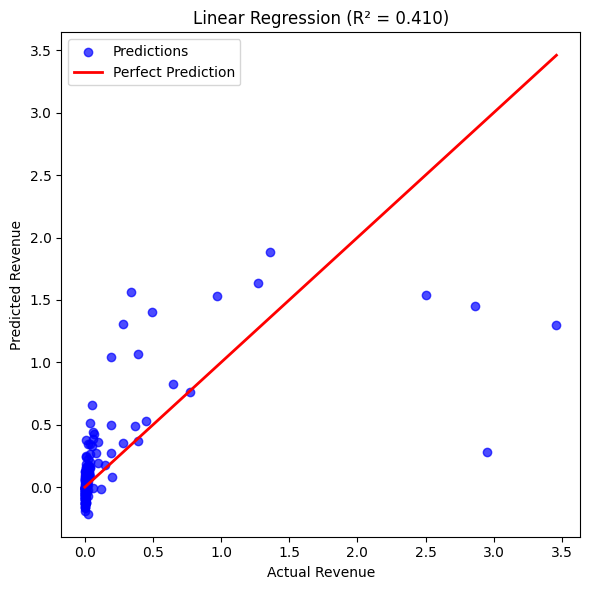


Training and evaluating: Random Forest

Random Forest
R²   : 0.6819
MAE  : 0.0766
RMSE : 0.2833


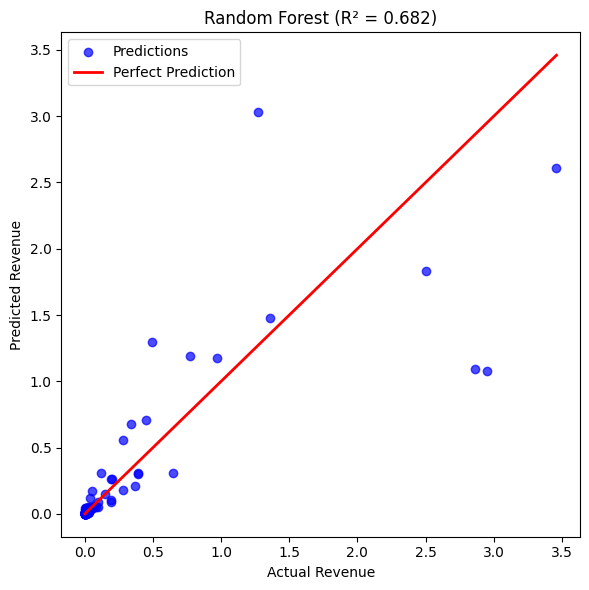


Training and evaluating: XGBoost

XGBoost
R²   : 0.7018
MAE  : 0.0728
RMSE : 0.2744


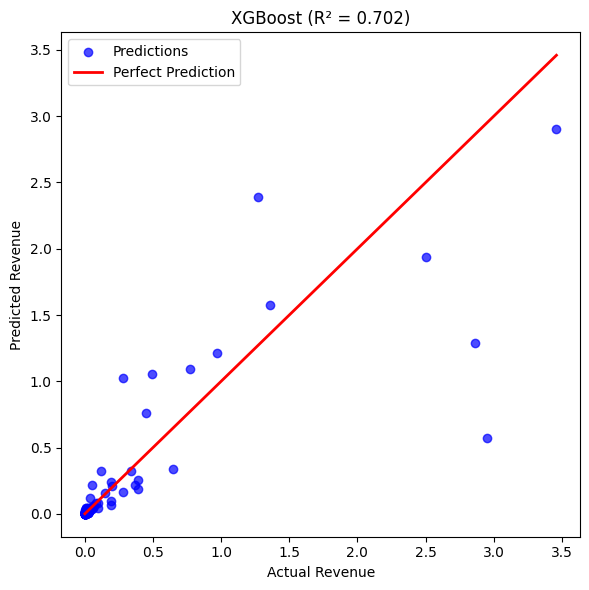


MODEL COMPARISON
               Model        R2       MAE      RMSE
0            XGBoost  0.701766  0.072836  0.274354
1      Random Forest  0.681936  0.076570  0.283328
2  Linear Regression  0.409985  0.181161  0.385890

BEST MODEL
     Model        R2       MAE      RMSE
0  XGBoost  0.701766  0.072836  0.274354

FEATURE IMPORTANCE
            Feature  Importance
11        Reach_log    0.762178
9   Impressions_log    0.095010
8        Shares_log    0.036122
10   Engagement_log    0.027270
5     hashtag_count    0.015707
6     Reactions_log    0.014875
4        word_count    0.014539
7      Comments_log    0.012880
3       day_encoded    0.012332
2      posting_hour    0.007111
1      type_encoded    0.001976
0   profile_encoded    0.000000


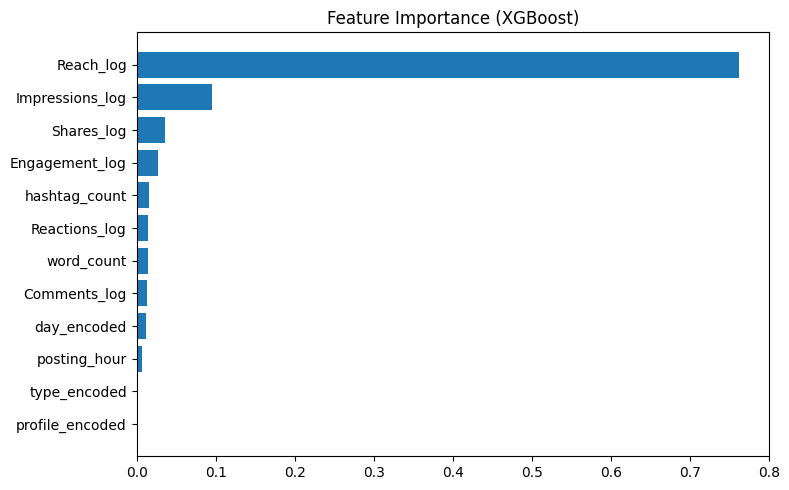


Missing Revenue values have been successfully predicted.
0


In [109]:
# Train & Evaluation

results = []

for model_name, model in models.items():

    print(f"\nTraining and evaluating: {model_name}")

    # Train model
    model.fit(X_train, y_train)

    # Prediction (log scale)
    y_pred_log = model.predict(X_test)

    # Back-transform to original scale
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred_log)

    # Evaluation (original scale)
    result = evaluate_model(
        model_name,
        y_test_actual,
        y_pred_actual
    )

    results.append(result)

    # Calculate R² for plot title
    r2 = r2_score(y_test_actual, y_pred_actual)

    # Actual vs Predicted Plot
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_actual,
        y_pred_actual,
        color="blue",
        alpha=0.7,
        label="Predictions"
    )

    plt.plot(
        [
            y_test_actual.min(),
            y_test_actual.max()
        ],
        [
            y_test_actual.min(),
            y_test_actual.max()
        ],
        color="red",
        linewidth=2,
        label="Perfect Prediction"
    )

    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.title(f"{model_name} (R² = {r2:.3f})")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Model Comparison

results_df = pd.DataFrame(results).sort_values(
    by="R2",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

print("\nMODEL COMPARISON")
print(results_df)

print("\nBEST MODEL")
print(results_df.head(1))


# Best Model

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]


# Train the best model using all available training data

best_model.fit(X, y)


# Feature Importance

if hasattr(best_model, "feature_importances_"):

    importance = (
        pd.DataFrame({
            "Feature": features,
            "Importance": best_model.feature_importances_
        })
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\nFEATURE IMPORTANCE")
    print(importance)

    plt.figure(figsize=(8, 5))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(f"Feature Importance ({best_model_name})")

    plt.tight_layout()
    plt.show()

else:

    print(f"{best_model_name} does not support feature importance.")


# Predict Missing Revenue

X_predict = predict_df[features]

# Predict on log scale
revenue_prediction_log = best_model.predict(X_predict)

# Convert back to original scale
revenue_prediction = np.expm1(revenue_prediction_log)

# Replace negative predictions with 0
revenue_prediction = np.maximum(revenue_prediction, 0)

df.loc[
    predict_df.index,
    "Content Monetization Revenue Estimation"
] = revenue_prediction

print("\nMissing Revenue values have been successfully predicted.")

print(
    df["Content Monetization Revenue Estimation"]
    .isna()
    .sum()
)

In [110]:
df.to_excel("facebook_data_final.xlsx", index=False)

# EDA

In [111]:
# Load final data
df_final = pd.read_excel("facebook_data_final.xlsx")

# Convert date column to datetime format
df_final["Date"] = pd.to_datetime(df_final["Date"],format="%m/%d/%Y %H:%M")

# Filter data for June 1–7, 2026
df_eda = df_final[(df_final["Date"] >= "2026-06-01") & (df_final["Date"] < "2026-06-08")].copy()

# Preview
df_eda.head()

,Profile,Link,Text,Date,Type,Reactions,Comments,Shares,Engagement,Impressions,...,posting_day,Engagement_log,Impressions_log,Reach_log,Reactions_log,Comments_log,Shares_log,profile_encoded,type_encoded,day_encoded
0,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,"Ditahan Kejagung, Akun Instagram Sony Sanjaya ...",2026-06-03 18:57:00,Photo,21,15,5,41,10016,...,Wednesday,3.737670,9.212039,8.632662,3.091042,2.772589,1.791759,4,1,6
1,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,NaN,2026-06-03 20:07:00,Photo,137,55,14,206,30989,...,Wednesday,5.332719,10.341420,9.815967,4.927254,4.025352,2.708050,4,1,6
2,Pikiran Rakyat,https://www.facebook.com/reel/1751324546030165/,Rekaman Penggeledahan Kantor dan Penangkapan K...,2026-06-03 20:17:00,Video,13,1,0,14,549,...,Wednesday,2.708050,6.309918,6.196444,2.639057,0.693147,0.000000,4,3,6
3,Pikiran Rakyat,https://www.facebook.com/PikiranRakyatMediaNet...,NaN,2026-06-03 20:26:00,Photo,3,1,1,5,681,...,Wednesday,1.791759,6.525030,6.122493,1.386294,0.693147,0.693147,4,1,6
4,Pikiran Rakyat,https://www.facebook.com/reel/985964620691136/,Rekaman CCTV Tunjukkan Momen Terminal Bandara ...,2026-06-03 21:20:00,Video,20,1,1,22,749,...,Wednesday,3.135494,6.620073,6.582025,3.044522,0.693147,0.693147,4,3,6


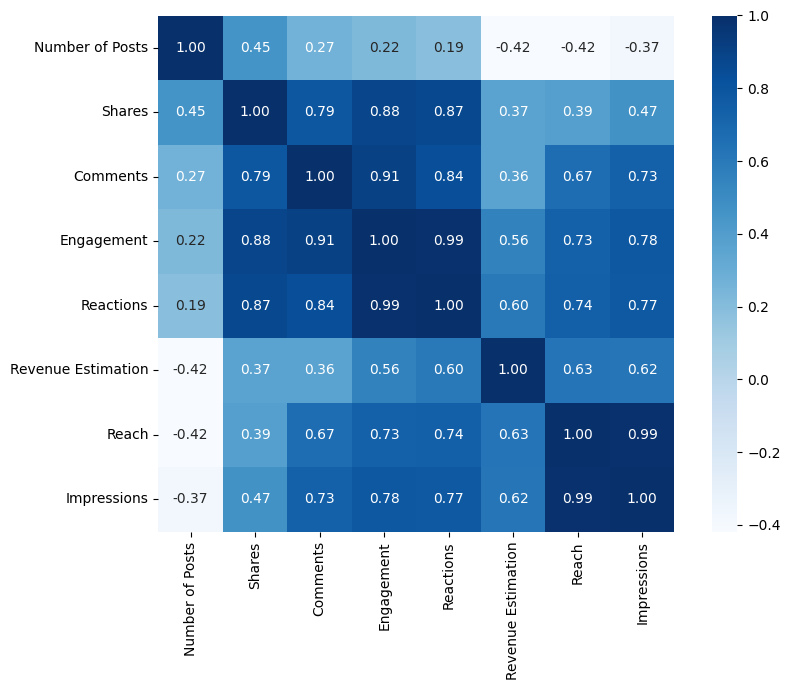

In [129]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Aggregate metrics by day
daily_metrics = (
    df_eda.groupby(df_eda["Date"].dt.normalize())
    .agg({
        "Profile": "count",
        "Shares": "sum",
        "Comments": "sum",
        "Engagement": "sum",
        "Reactions": "sum",
        "Content Monetization Revenue Estimation": "sum",
        "Reach": "sum",
        "Impressions": "sum"
    })
    .rename(columns={
        "Profile": "Number of Posts",
        "Content Monetization Revenue Estimation": "Revenue Estimation"
    })
)

# Calculate correlation matrix
corr_matrix = daily_metrics.corr()

# Plot correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)

# plt.title("Daily Metrics Correlation Heatmap")
plt.tight_layout()
plt.show()

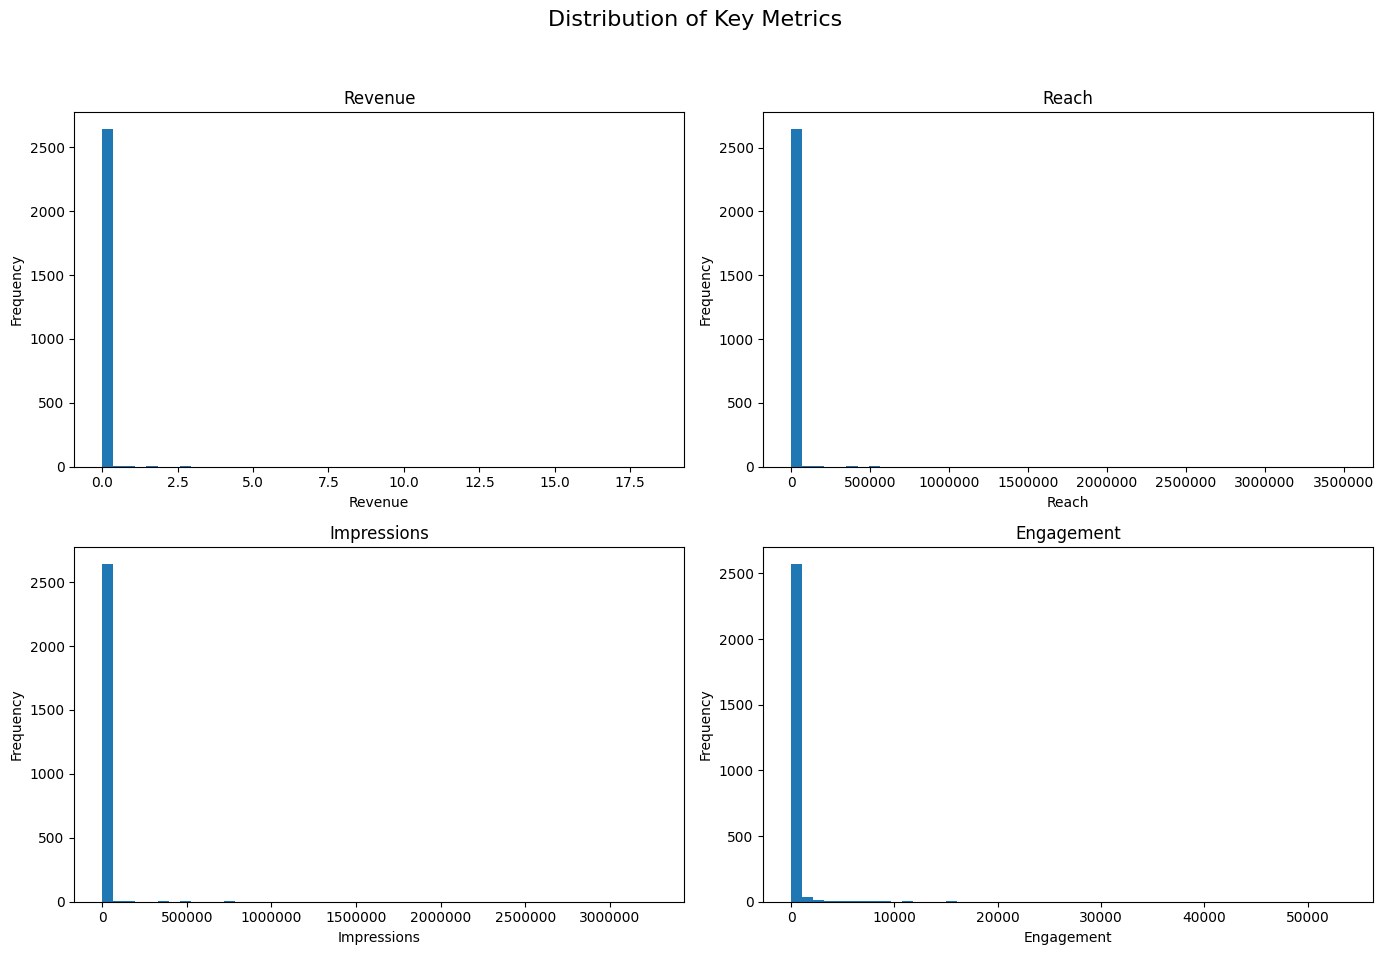

In [131]:
# Distribution Analysis
metrics_to_plot = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Engagement": "Engagement"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Key Metrics", fontsize=16)

for ax, (title, column) in zip(axes.flat, metrics_to_plot.items()):
    ax.hist(df_eda[column], bins=50)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Total Revenue by Profile
Profile
Pikiran Rakyat    65.070000
Suara.com         15.787670
Kompas             4.525403
Antaranews         4.132437
Detik              2.288937
Tribunnews         1.576128
Kumparan           1.504583
SindoNews          0.818740
Name: Content Monetization Revenue Estimation, dtype: float64

Total Reach by Profile
Profile
Pikiran Rakyat    10836863
Suara.com          1983553
Kompas              347525
Antaranews          248699
Detik               173160
Tribunnews           98137
SindoNews            77844
Kumparan             33411
Name: Reach, dtype: int64

Total Impressions by Profile
Profile
Pikiran Rakyat    10727706
Suara.com          2061146
Antaranews          576904
Kompas              379547
Detik               187587
Tribunnews          101897
SindoNews            78116
Kumparan             33833
Name: Impressions, dtype: int64

Total Engagement by Profile
Profile
Suara.com         342356
Pikiran Rakyat    164821
Kompas             64580
Antarane

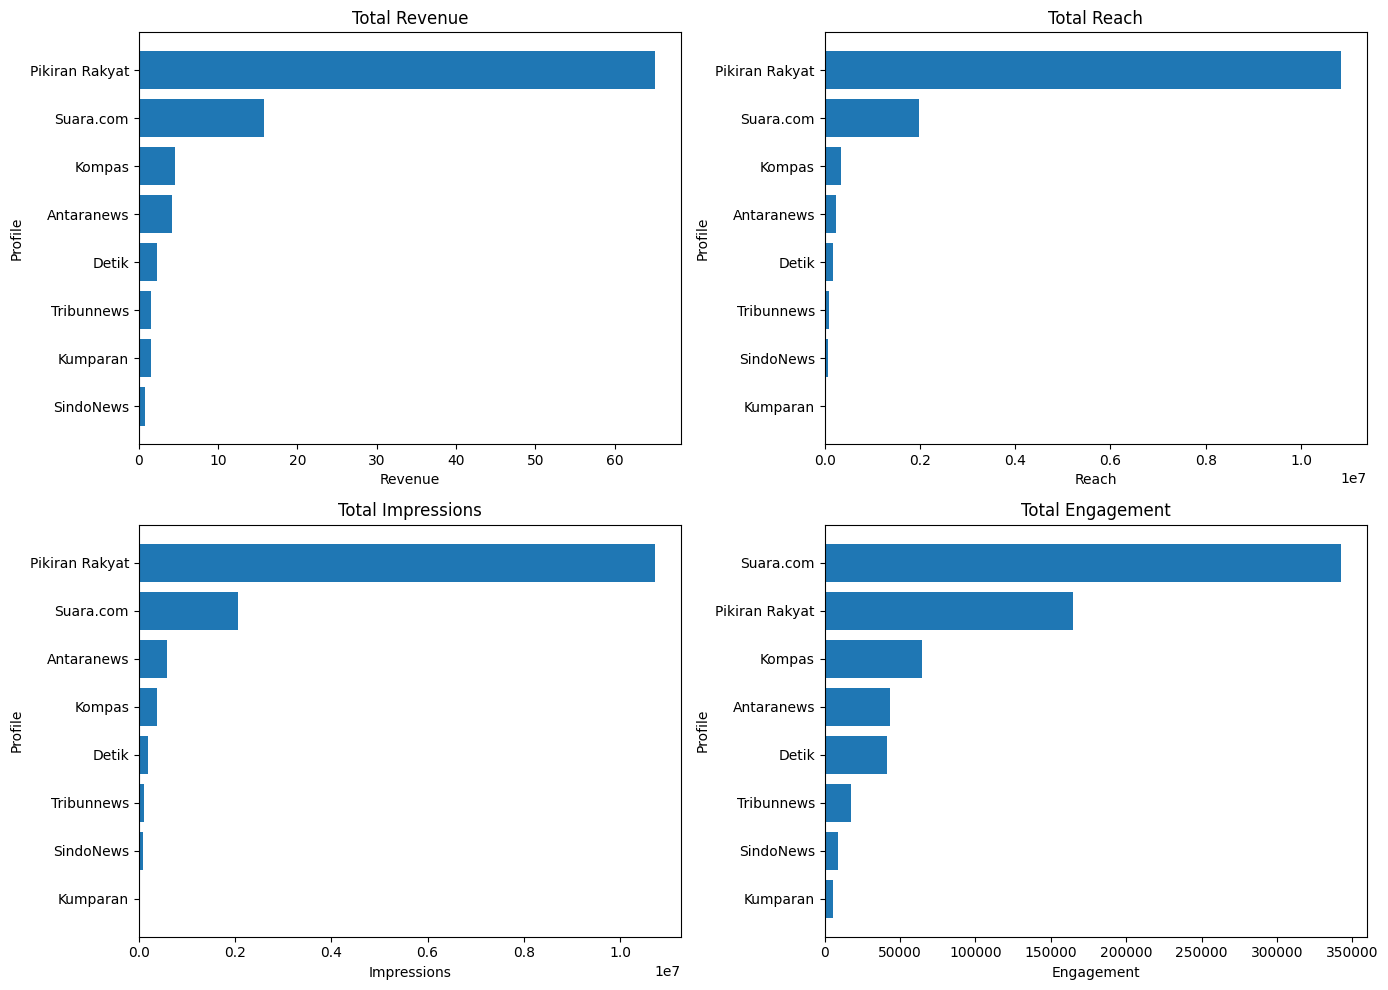

In [113]:
# Total metrics by profile

metrics = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Engagement": "Engagement"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, column) in zip(axes.flat, metrics.items()):

    metric_per_profile = (
        df_eda.groupby("Profile")[column]
        .sum()
        .sort_values(ascending=False)
    )

    print(f"\nTotal {title} by Profile")
    print(metric_per_profile)

    ax.barh(
        metric_per_profile.index,
        metric_per_profile.values
    )

    ax.set_title(f"Total {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Profile")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


Median Revenue by Post Type
Type
Video    0.010000
Text     0.010000
Photo    0.006693
Link     0.002784
Name: Content Monetization Revenue Estimation, dtype: float64

Median Reach by Post Type
Type
Video    2250.0
Photo     640.0
Text      570.0
Link       31.0
Name: Reach, dtype: float64

Median Impressions by Post Type
Type
Video    2178.0
Photo     660.0
Text      577.0
Link       31.0
Name: Impressions, dtype: float64

Median Reactions by Post Type
Type
Photo    42.5
Text     29.0
Video    25.5
Link      2.0
Name: Reactions, dtype: float64


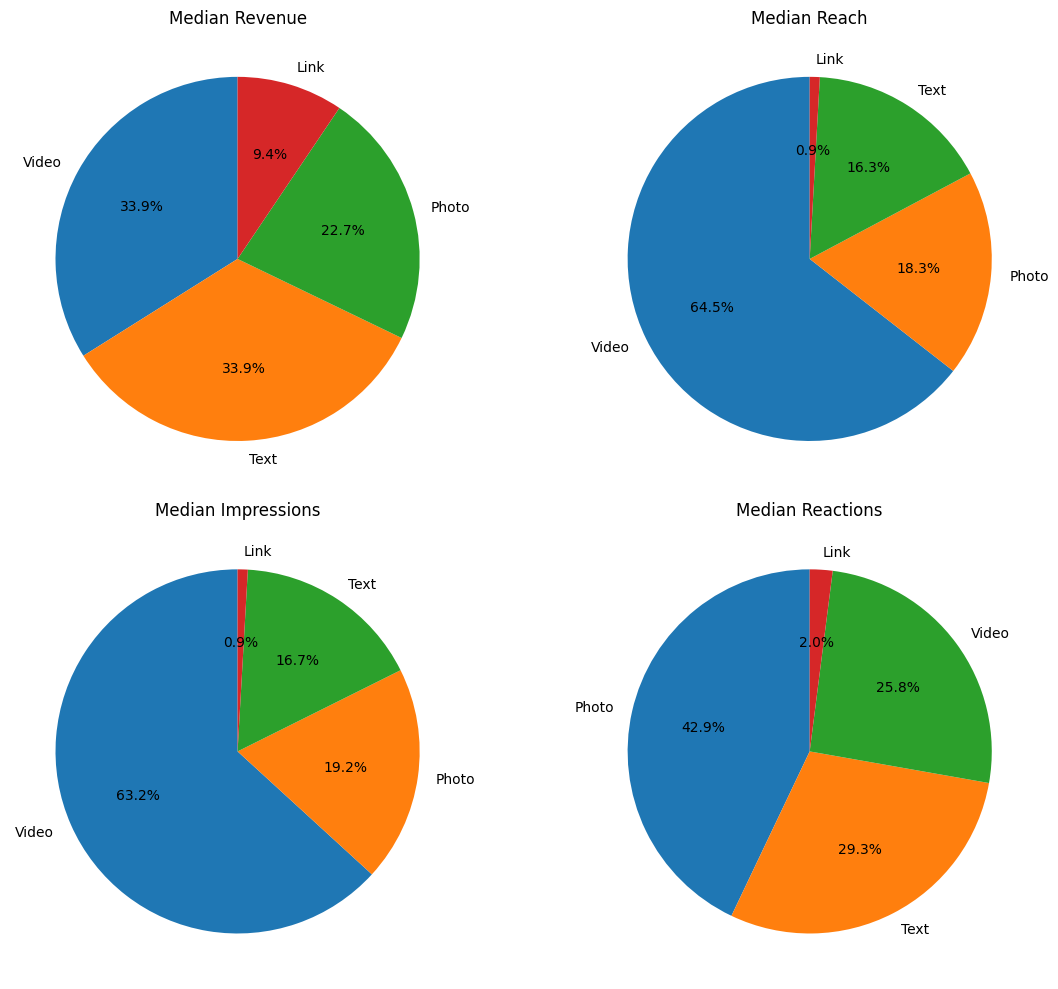

In [114]:
# Median metrics by post type

metrics = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Reactions": "Reactions"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (title, column) in zip(axes.flat, metrics.items()):

    median_values = (
        df_eda.groupby("Type")[column]
        .median()
        .sort_values(ascending=False)
    )

    print(f"\nMedian {title} by Post Type")
    print(median_values)

    ax.pie(
        median_values,
        labels=median_values.index,
        autopct="%1.1f%%",
        startangle=90
    )

    ax.set_title(f"Median {title}")

plt.tight_layout()
plt.show()


Median Revenue by Word Count
word_count
231    18.360000
218     4.860669
105     3.345935
107     2.950000
223     2.274983
289     0.924470
154     0.670000
550     0.554165
486     0.478373
182     0.393016
Name: Content Monetization Revenue Estimation, dtype: float64

Median Impressions by Word Count
word_count
231     747366.0
218    1638014.0
105     268951.0
107     329497.0
223     209225.5
289     419486.0
154      84748.0
550     135308.0
486      72314.0
182      55597.5
Name: Impressions, dtype: float64

Median Reach by Word Count
word_count
231     755922.0
218    1755629.5
105     278952.0
107     368475.0
223     222446.0
289     466823.5
154      85703.0
550     119452.0
486      67757.0
182      48695.5
Name: Reach, dtype: float64

Median Engagement by Word Count
word_count
231     6540.0
218    26916.5
105     8021.0
107     9485.0
223      880.5
289     7615.5
154     1499.0
550    23108.0
486    11706.0
182    12917.0
Name: Engagement, dtype: float64


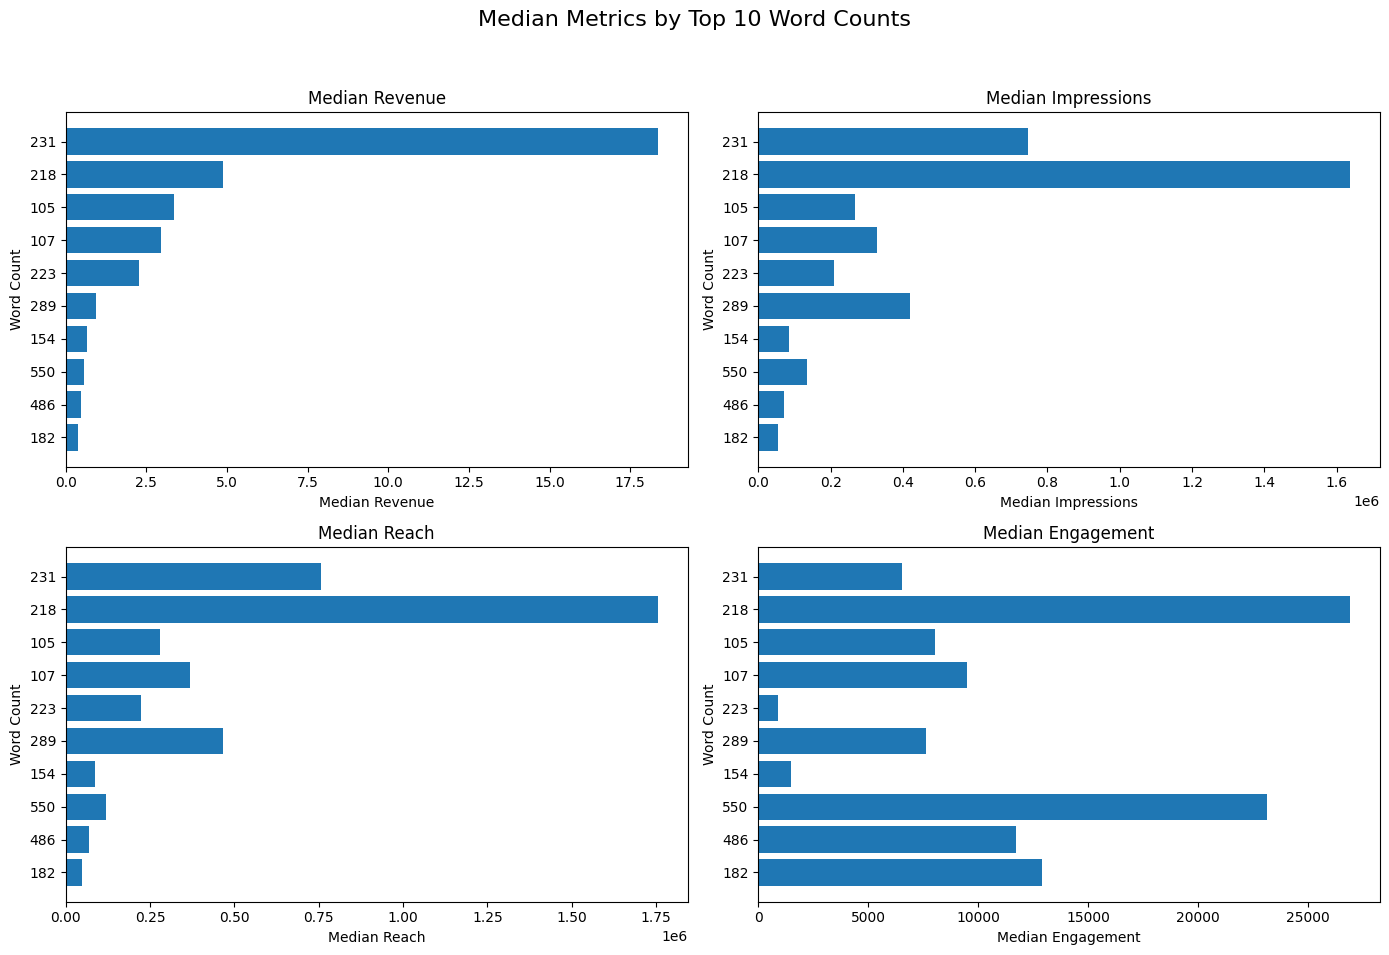

In [133]:
metrics_for_word_count = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Impressions": "Impressions",
    "Reach": "Reach",
    "Engagement": "Engagement"
}

# Calculate median revenue by word count and get the top 10 word counts
top_10_word_counts = (
    df_eda.groupby("word_count")["Content Monetization Revenue Estimation"]
    .median()
    .nlargest(10)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Median Metrics by Top 10 Word Counts", fontsize=16)

for ax, (title, column) in zip(axes.flat, metrics_for_word_count.items()):
    median_metric_by_word_count = (
        df_eda[df_eda["word_count"].isin(top_10_word_counts)]
        .groupby("word_count")[column]
        .median()
        .reindex(top_10_word_counts)
    )

    print(f"\nMedian {title} by Word Count")
    print(median_metric_by_word_count)

    ax.barh(
        median_metric_by_word_count.index.astype(str),
        median_metric_by_word_count.values
    )

    ax.set_title(f"Median {title}")
    ax.set_xlabel(f"Median {title}")
    ax.set_ylabel("Word Count")
    ax.invert_yaxis() # Invert y-axis to show highest values at the top

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Median Revenue by Hashtag Presence
hashtag_presence
Without Hashtag    0.002784
With Hashtag       0.003033
Name: Content Monetization Revenue Estimation, dtype: float64

Median Reach by Hashtag Presence
hashtag_presence
Without Hashtag    136.0
With Hashtag       123.0
Name: Reach, dtype: float64

Median Impressions by Hashtag Presence
hashtag_presence
Without Hashtag    136.5
With Hashtag       123.0
Name: Impressions, dtype: float64

Median Engagement by Hashtag Presence
hashtag_presence
Without Hashtag    8.0
With Hashtag       8.0
Name: Engagement, dtype: float64


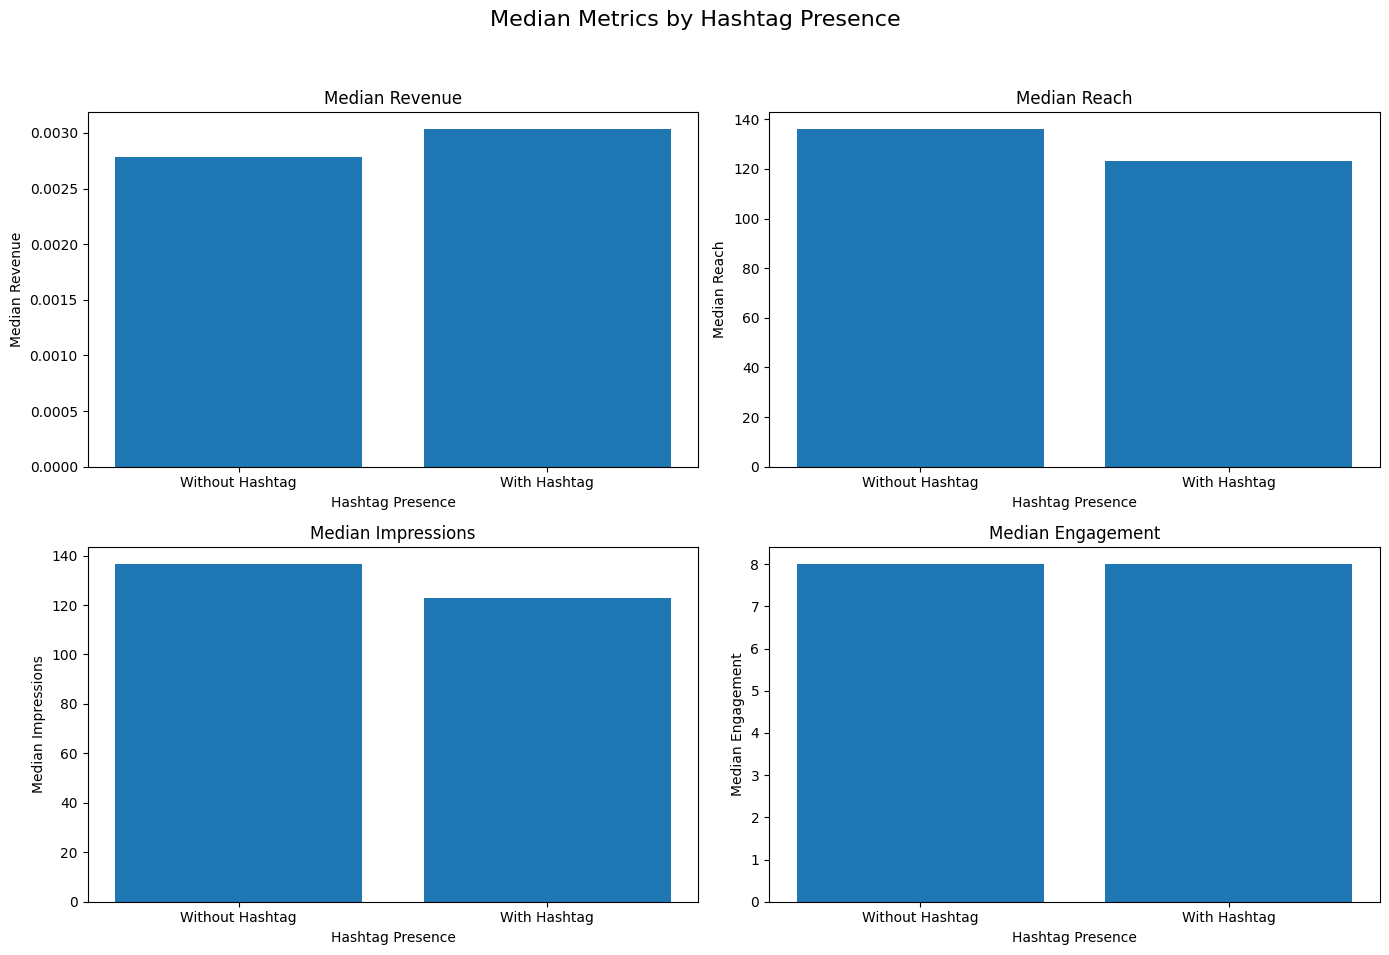

In [134]:
# Create a new column to indicate hashtag presence
df_eda['hashtag_presence'] = df_eda['hashtag_count'].apply(lambda x: 'With Hashtag' if x > 0 else 'Without Hashtag')

# Metrics to analyze
metrics_for_hashtag = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Engagement": "Engagement"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Median Metrics by Hashtag Presence", fontsize=16)

for ax, (title, column) in zip(axes.flat, metrics_for_hashtag.items()):
    median_metric_by_hashtag = (
        df_eda.groupby('hashtag_presence')[column]
        .median()
        .reindex(['Without Hashtag', 'With Hashtag']) # Ensure consistent order
    )

    print(f"\nMedian {title} by Hashtag Presence")
    print(median_metric_by_hashtag)

    ax.bar(
        median_metric_by_hashtag.index,
        median_metric_by_hashtag.values
    )

    ax.set_title(f"Median {title}")
    ax.set_xlabel("Hashtag Presence")
    ax.set_ylabel(f"Median {title}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Median Revenue by Day of Week
Day of Week
Monday       0.002935
Tuesday      0.003039
Wednesday    0.003019
Thursday     0.002784
Friday       0.002907
Saturday     0.002965
Sunday       0.002965
Name: Content Monetization Revenue Estimation, dtype: float64

Median Reach by Day of Week
Day of Week
Monday       142.0
Tuesday      247.5
Wednesday    168.5
Thursday     127.0
Friday       184.0
Saturday      36.0
Sunday        50.0
Name: Reach, dtype: float64

Median Impressions by Day of Week
Day of Week
Monday       143.0
Tuesday      248.0
Wednesday    169.0
Thursday     127.0
Friday       184.0
Saturday      37.0
Sunday        50.0
Name: Impressions, dtype: float64

Median Reactions by Day of Week
Day of Week
Monday        7.0
Tuesday      14.0
Wednesday    10.0
Thursday      7.0
Friday        9.0
Saturday      3.0
Sunday        4.0
Name: Reactions, dtype: float64


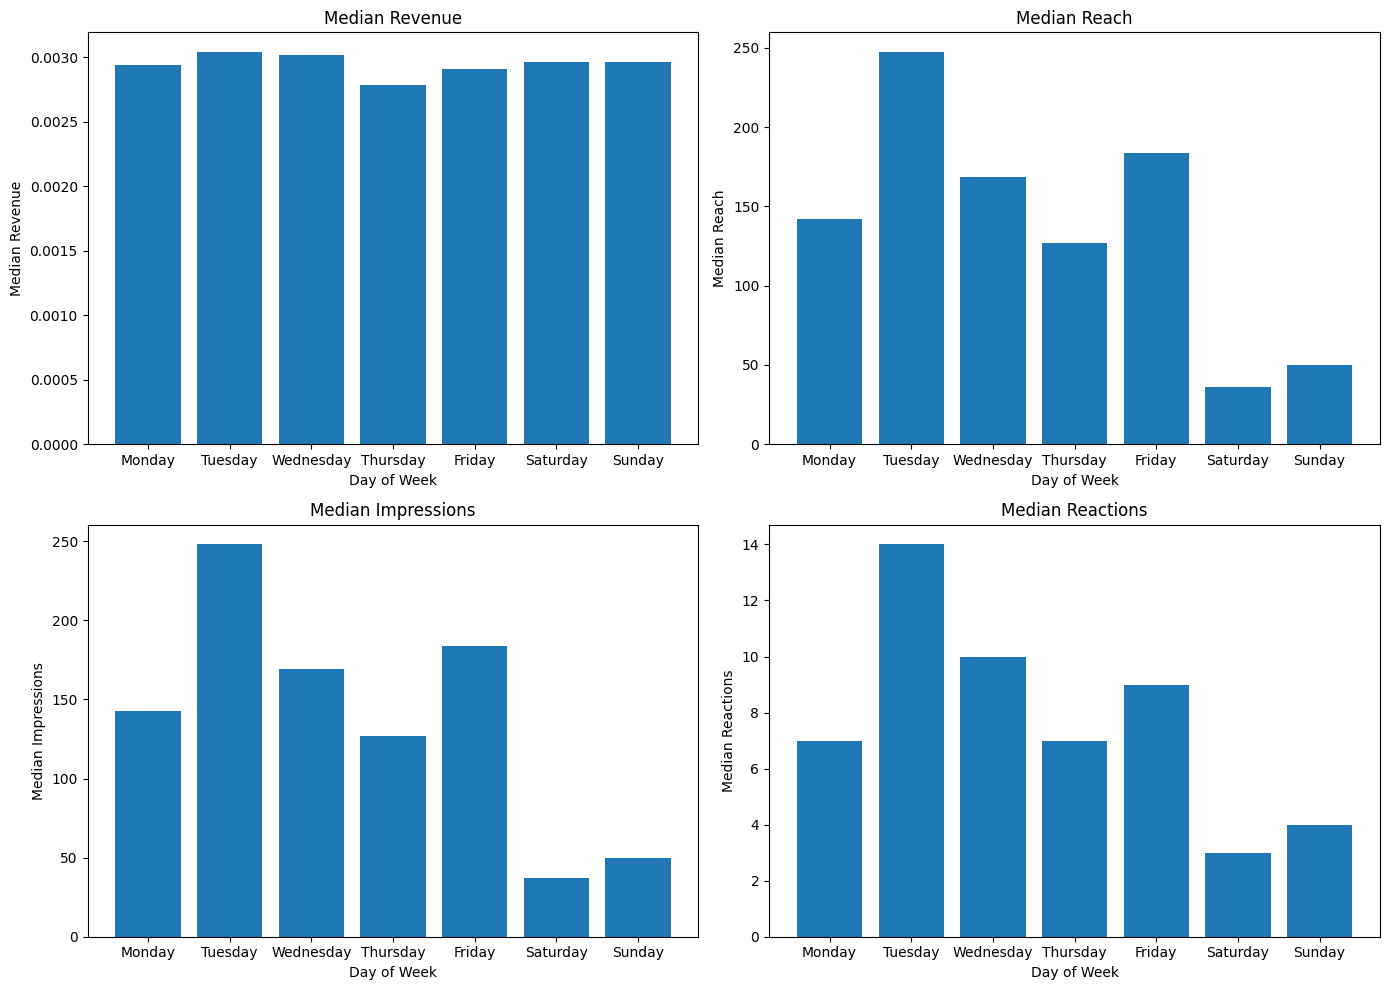

In [115]:
# Extract day name from posting date
df_eda["Day of Week"] = df_eda["Date"].dt.day_name()

# Define day order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Metrics to analyze
metrics = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Reactions": "Reactions"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, column) in zip(axes.flat, metrics.items()):

    median_metric = (
        df_eda.groupby("Day of Week")[column]
        .median()
        .reindex(day_order)
    )

    print(f"\nMedian {title} by Day of Week")
    print(median_metric)

    ax.bar(
        median_metric.index,
        median_metric.values
    )

    ax.set_title(f"Median {title}")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel(f"Median {title}")

    ax.tick_params(axis="x")

plt.tight_layout()
plt.show()


Median Revenue by Post Hour
Post Hour
0     0.002593
1     0.002907
2     0.002907
3     0.002935
4     0.002784
5     0.002784
6     0.002784
7     0.002784
8     0.002784
9     0.002935
10    0.003033
11    0.003033
12    0.003033
13    0.002935
14    0.002935
15    0.002935
16    0.003033
17    0.003033
18    0.002935
19    0.002935
20    0.002784
21    0.002965
22    0.002935
23    0.003161
Name: Content Monetization Revenue Estimation, dtype: float64

Median Reach by Post Hour
Post Hour
0      33.0
1      51.0
2      90.0
3     160.0
4      50.0
5      47.0
6      53.0
7      36.0
8      94.0
9     114.0
10    152.0
11    157.0
12    125.0
13    127.5
14    112.0
15    124.5
16    135.0
17    141.0
18    185.0
19    177.0
20    148.0
21    287.0
22    230.0
23    274.0
Name: Reach, dtype: float64

Median Impressions by Post Hour
Post Hour
0      33.0
1      51.0
2      90.0
3     160.0
4      50.0
5      47.0
6      53.0
7      37.0
8      94.0
9     114.0
10    152.5
11    157.0

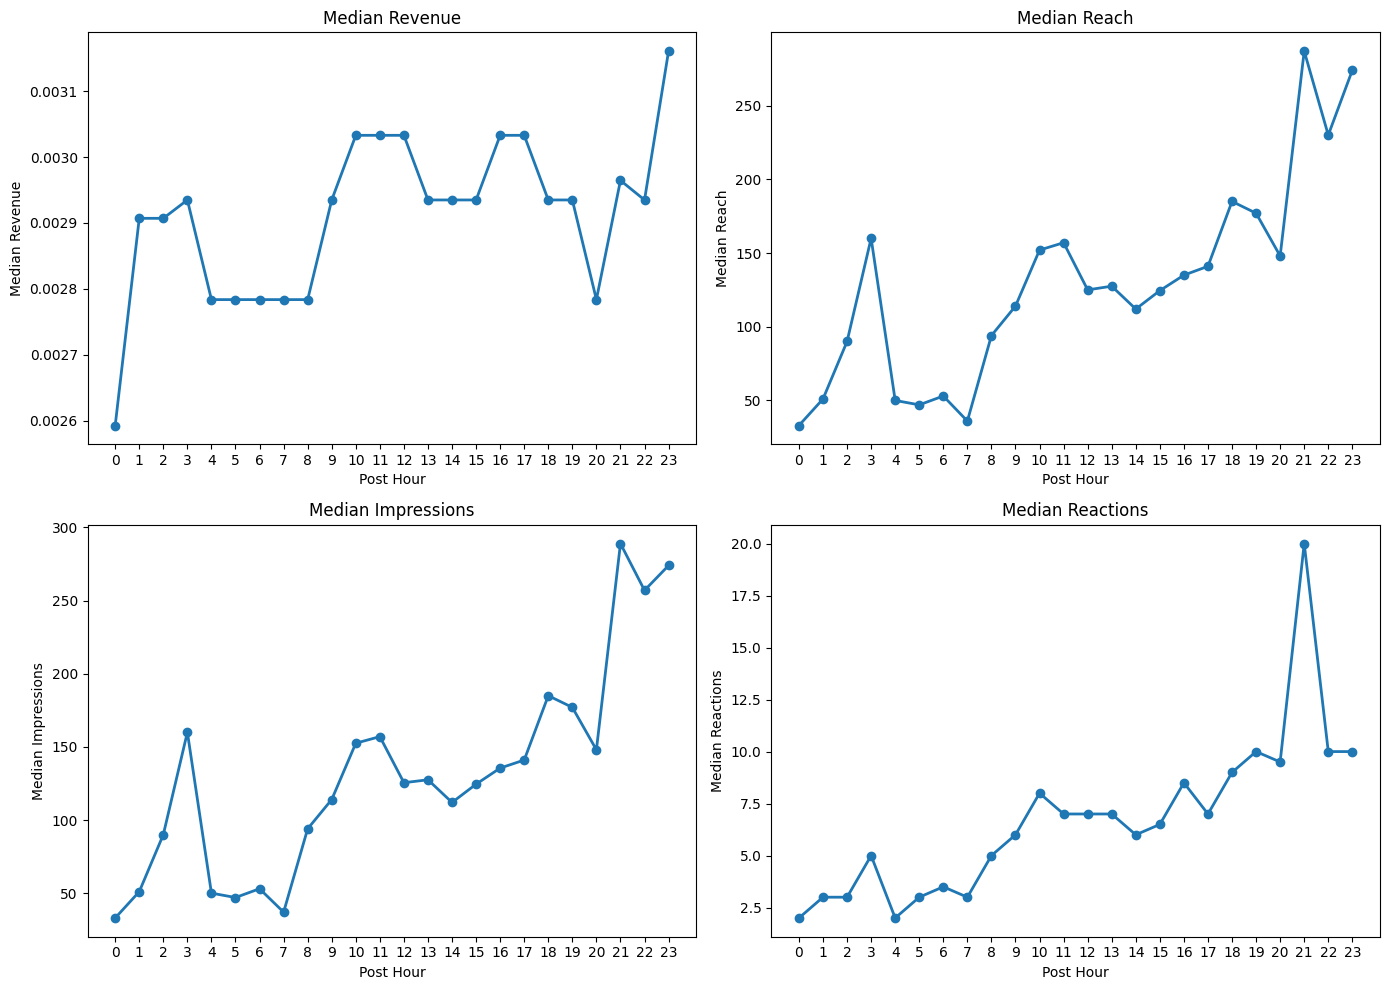

In [116]:
# Extract posting hour
df_eda["Post Hour"] = df_eda["Date"].dt.hour

# Metrics to analyze
metrics = {
    "Revenue": "Content Monetization Revenue Estimation",
    "Reach": "Reach",
    "Impressions": "Impressions",
    "Reactions": "Reactions"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, column) in zip(axes.flat, metrics.items()):

    median_metric = (
        df_eda.groupby("Post Hour")[column]
        .median()
        .reindex(range(24))
    )

    print(f"\nMedian {title} by Post Hour")
    print(median_metric)

    ax.plot(
        median_metric.index,
        median_metric.values,
        marker="o",
        linewidth=2
    )

    ax.set_title(f"Median {title}")
    ax.set_xlabel("Post Hour")
    ax.set_ylabel(f"Median {title}")
    ax.set_xticks(range(24))

plt.tight_layout()
plt.show()